### Production ConvNeXtLarge CNN Training Using SAM-Processed Chum Salmon Scale Images

This script trains the production ConvNeXtLarge convolutional neural network using SAM-processed chum salmon scale images from AFSC, ADF&G, DFO, and NSRAA.

The SAM-processed images were randomly divided into training (70%), validation (15%), and test (15%) datasets, stratified by total age to maintain a similar age-class distribution across each dataset. Each dataset was stored in a separate directory on disk.

The script loads and standardizes the images and trains the model using a two-phase transfer-learning strategy. The final trained model, including its architecture and learned weights, is saved to disk for subsequent evaluation and inference.

Date: 09/09/20259/2025

In [1]:
#loading packages

from PIL import Image
import numpy as np
import pandas as pd
import tensorrt
import io
import numpy.random as nr
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
import keras.layers as layers
from keras import optimizers
import time

%matplotlib inline

2025-09-10 23:37:34.116829: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
start = time.time()

In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    print(e)

2 Physical GPUs, 2 Logical GPUs


2025-09-10 23:37:35.407531: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-10 23:37:35.407680: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-09-10 23:37:35.413383: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

### Counting images in folder

In [4]:
# counting the total number of images within the folder
import glob
import random
import os, shutil

import os

def count_images_in_folder(folder_path):
    if not folder_path.endswith('/'):
        folder_path += '/'
    
    files = os.listdir(folder_path)
    
    image_extensions = ('.png', '.tif', '.tiff', '.jpg', '.jpeg')
    
    image_files = [f for f in files if f.lower().endswith(image_extensions)]
    
    num_images = len(image_files)

    return num_images

folder_training_path = '/opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Training' 
folder_validation_path = '/opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Validation'

num_images = count_images_in_folder(folder_training_path)
print(f'Number of images in {folder_training_path}: {num_images}')

Number of images in /opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Training: 11012


### Counting images in folder by age class

In [5]:
import os

def count_images_in_folder(folder_path):
    if not folder_path.endswith('/'):
        folder_path += '/'
    
    image_extensions = ('.png', '.tif', '.tiff', '.jpg', '.jpeg')
    
    files = os.listdir(folder_path)

    counts = {
        '_1': 0, '_2': 0, '_3': 0, '_4': 0,
        '_5': 0, '_6': 0, '_7': 0
    }
    
    for file in files:
        if file.lower().endswith(image_extensions):
            base_name = os.path.splitext(file)[0].lower()
            
            for suffix in counts.keys():
                if base_name.endswith(suffix):
                    counts[suffix] += 1
                    break

    return counts

counts = count_images_in_folder(folder_training_path)
print(f"Counts of images in {folder_training_path}:")
for suffix, count in counts.items():
    print(f"{suffix}: {count}")

Counts of images in /opt/chumputer/scale_images/Image_copies_code_testing_SAMgood/Training:
_1: 123
_2: 76
_3: 2767
_4: 4265
_5: 3602
_6: 172
_7: 7


In [6]:
# loop through image in memory and extracts the age class label from the end of the file name 
# and creates a pandas dataframe that includes the filename and label (total age).

import os

def load_images_from_folder(folder_path):
    labels = ['_1', '_2', '_3', '_4', '_5', '_6', '_7']
    files_by_label = {label: [] for label in labels}
    
    for file in os.listdir(folder_path):
        for label in labels:
            if file.lower().endswith(label + '.png') or \
               file.lower().endswith(label + '.jpg') or \
               file.lower().endswith(label + '.jpeg') or \
               file.lower().endswith(label + '.tif') or \
               file.lower().endswith(label + '.tiff'):
                files_by_label[label].append(file)  # <-- fixed here
    
    data = [(file, label) for label, files in files_by_label.items() for file in files]
    
    return pd.DataFrame(data, columns=['filename', 'label'])

# Load images from both the training and validation folders
df_train = load_images_from_folder(folder_training_path)
df_val = load_images_from_folder(folder_validation_path)

# Print samples of the data
print("Training set sample:")
print(df_train.head())
print(f"Total images in training set: {len(df_train)}")

print("\nValidation set sample:")
print(df_val.head())
print(f"Total images in validation set: {len(df_val)}")


Training set sample:
                  filename label
0   Chum_SCL_2004_92_1.tif    _1
1  Chum_SCL_2002_144_1.tif    _1
2   Chum_SCL_2007_16_1.tif    _1
3   Chum_SCL_2004_95_1.tif    _1
4  Chum_SCL_2002_129_1.tif    _1
Total images in training set: 11012

Validation set sample:
                  filename label
0   Chum_SCL_2006_07_1.tif    _1
1  Chum_SCL_2002_115_1.tif    _1
2  Chum_SCL_2002_125_1.tif    _1
3   Chum_SCL_2011_01_1.tif    _1
4  Chum_SCL_2002_148_1.tif    _1
Total images in validation set: 2365


In [7]:
# this simply removes the underscore that was used to separate file name from the age value

df_val['label'] = df_val['label'].str.replace(r'_(\d+)', r'\1', regex=True)
df_val['label'] = pd.to_numeric(df_val['label'], errors='coerce')

df_train['label'] = df_train['label'].str.replace(r'_(\d+)', r'\1', regex=True)
df_train['label'] = pd.to_numeric(df_train['label'], errors='coerce')

df_train.head()

,filename,label
0,Chum_SCL_2004_92_1.tif,1
1,Chum_SCL_2002_144_1.tif,1
2,Chum_SCL_2007_16_1.tif,1
3,Chum_SCL_2004_95_1.tif,1
4,Chum_SCL_2002_129_1.tif,1


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11012 entries, 0 to 11011
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  11012 non-null  object
 1   label     11012 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 172.2+ KB


In [9]:
# separating the file name and age label into two separate lists but they maintain the same index
val_images_link = df_val['filename'].tolist()
val_labels = df_val['label'].tolist()

train_images_link = df_train['filename'].tolist()
train_labels = df_train['label'].tolist()

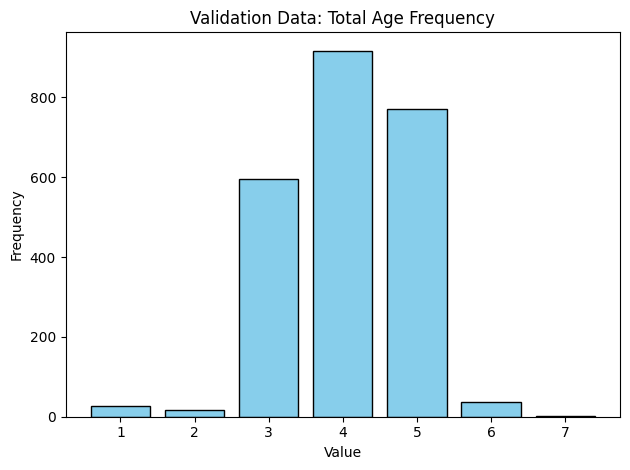

In [10]:
# show distribution by age class
from collections import Counter

count_data = Counter(val_labels)

x = list(count_data.keys())
y = list(count_data.values())

plt.bar(x, y, color='skyblue', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Validation Data: Total Age Frequency')

plt.tight_layout()
#plt.savefig('ValidationAgeLabels.pdf') 
plt.show()

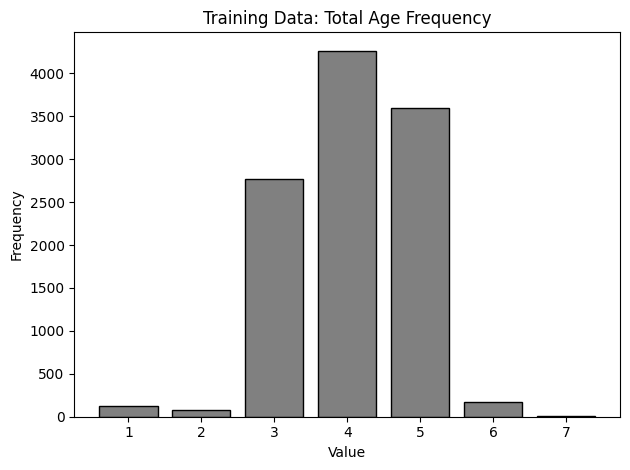

In [11]:
# show distribution by age class
count_data = Counter(train_labels)

x = list(count_data.keys())
y = list(count_data.values())

plt.bar(x, y, color='gray', edgecolor='black')

plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Training Data: Total Age Frequency')

plt.tight_layout()
#plt.savefig('TrainingAgeLabels.pdf') 
plt.show()

In [12]:
# This is a key cell block, it links the file name from the image list
# Those images are resized and then into a dict. 
# The index is maintained from the train_images_link in order to link them back to the age labels 
# This step is very efficient if the computer has sufficient memory otherwise batch processing would be necessary.

train_images = {}
val_images = {}
def load_images(image_filenames, folder_path):

    images = {}
    target_size = (512, 512)
    
    for filename in image_filenames:
        file_path = os.path.join(folder_path, filename)
        if os.path.exists(file_path):
            with Image.open(file_path) as img:
                resized_img = img.resize(target_size, Image.LANCZOS)
                images[filename] = resized_img.copy()
        else:
            print(f"File {filename} not found in {folder_path}")
    
    return images

train_images = load_images(train_images_link, folder_training_path)
val_images = load_images(val_images_link, folder_validation_path)

In [13]:
# This block creates two functions to make sure all images have 3-channe, ie are color images, and if not to covert them regardless of the image imput type. 
# Important: The Keras models used in this project require all input images to be in color, have 3-channels
import cv2
from tqdm import tqdm

def process_image(img):

    if not isinstance(img, Image.Image):
        raise TypeError("Input has to be a PIL.Image.Image object.")
    
    img_np = np.array(img)
    
    print(f"Processing image with shape: {img_np.shape}")
    
    if len(img_np.shape) == 2:
        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
    elif len(img_np.shape) == 3:
        if img_np.shape[2] == 1:
            img_rgb = np.repeat(img_np, 3, axis=2)
        elif img_np.shape[2] == 3:
            img_rgb = img_np
        else:
            raise ValueError(f"Unexpected number of channels in the image: {img_np.shape[2]}")
    else:
        raise ValueError(f"Unexpected image dimensions: {img_np.shape}")
    
    return img_rgb

def process_images(image_dict):
    processed_images = []
    error_count = 0
    for filename, img in tqdm(image_dict.items(), desc="Processing Images"):
        try:
            processed_img = process_image(img)
            processed_images.append(processed_img)
        except (TypeError, ValueError) as e:
            print(f"Error processing {filename}: {e}")
            error_count += 1
    
    print(f"Number of errors: {error_count}")
    return processed_images


In [14]:
# This code running the above functions, creating the images to array and normalizing them. 
processed_train_images = process_images(train_images)
processed_train_images = np.array(processed_train_images)
x_train = processed_train_images.astype("float32") / 255

processed_val_images = process_images(val_images) 
processed_val_images = np.array(processed_val_images)
x_val = processed_val_images.astype("float32") / 255


for img in val_images.values():
    img.close()
for img in train_images.values():
    img.close()

Processing Images:   3%|█▊                                                        | 341/11012 [00:00<00:06, 1706.99it/s]

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images:   6%|███▋                                                      | 690/11012 [00:00<00:05, 1727.29it/s]

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images:   8%|████▌                                                     | 874/11012 [00:00<00:05, 1764.70it/s]

...

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images:  91%|████████████████████████████████████████████████████▊     | 2151/2365 [00:01<00:00, 1795.67it/s]

Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

Processing Images: 100%|██████████████████████████████████████████████████████████| 2365/2365 [00:01<00:00, 1787.48it/s]


Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing image with shape: (512, 512, 3)
Processing 

In [15]:
# Count of images in memory
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_val.shape[0], "val samples")

x_train shape: (11012, 512, 512, 3)
11012 train samples
2365 val samples


In [16]:
# subtracting 1 from the labels. We don't have an zero total ages
y_val_class = np.asarray([float(num) - 1 for num in val_labels])
y_train_class = np.asarray([float(num) - 1 for num in train_labels])

In [17]:
import gc

del train_images, val_images, df_train, df_val, processed_train_images, processed_val_images
gc.collect()

0

In [18]:
tf.keras.backend.clear_session()

In [19]:
# Checking available GPUs 
print("GPU available: ", tf.config.list_physical_devices('GPU'))

GPU available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [20]:
#Create a MirroredStrategy for multi-GPU usage
strategy = tf.distribute.MirroredStrategy()

print(f"Number of devices: {strategy.num_replicas_in_sync}")

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Optional: Function to add noise (if needed)
def add_noise(image):
    noise_factor = 0.05  # Adjust noise level
    noise = np.random.normal(0, noise_factor, image.shape)
    image_noisy = image + noise
    return np.clip(image_noisy, 0., 255.)

datagen = ImageDataGenerator(
    rotation_range=360,
    vertical_flip=True,
    horizontal_flip=True,  
    shear_range=0.15,  
    zoom_range=[0.97, 1.02],
    height_shift_range=0.04,  
    width_shift_range=0.04,
    fill_mode='constant',
    cval=0,
#    preprocessing_function=add_noise  # This was not included in the augmentation. 
)

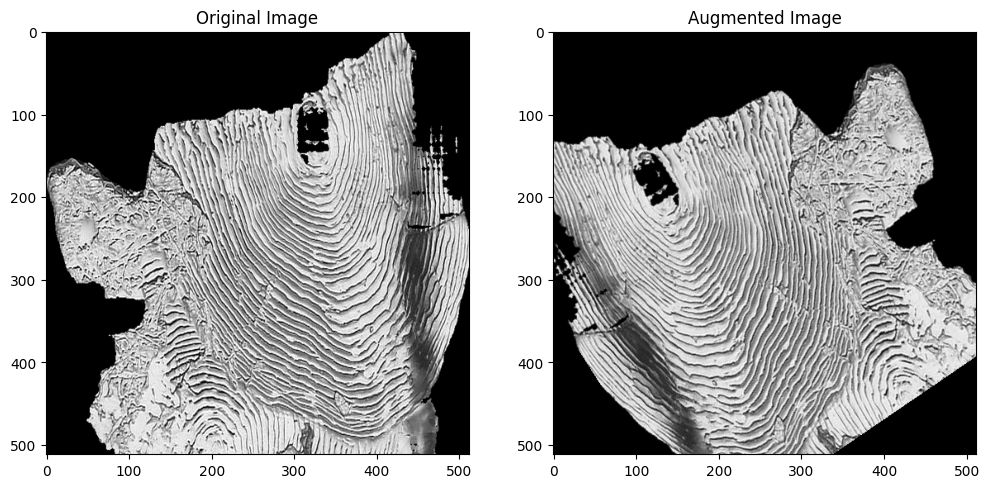

In [22]:
index_to_visualize = 33
image_to_visualize = x_train[index_to_visualize]

image_to_visualize = np.expand_dims(image_to_visualize, axis=0)

plt.figure(figsize=(12, 12))
plt.subplot(1, 2, 1)
plt.imshow(image_to_visualize[0])
plt.title('Original Image')

augmented_image = datagen.flow(image_to_visualize).next()[0]

plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title('Augmented Image')

#plt.savefig('ExampleAugmentedImageProcess.pdf')
plt.show()

### Loading ConvNeXtLarge model

In [23]:
import tensorflow as tf
from tensorflow.keras.applications import ConvNeXtLarge 
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers.legacy import Adam  #  legacy version to avoid KeyError
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f"Number of devices: {strategy.num_replicas_in_sync}")

Number of devices: 2


In [24]:
strategy = tf.distribute.MirroredStrategy()

input_shape = (512, 512, 3)
batch_size = 16
learning_rate = 1e-4
max_epochs = 80
initial_epochs = 50
patience = 9

ConvNeXtLarge_train_generator = datagen.flow(x_train, y_train_class, batch_size=batch_size)

with strategy.scope():
    pretrained_ConvNeXtLarge = ConvNeXtLarge(
        weights='imagenet',
        include_top=False,
        include_preprocessing=False,
        pooling=None,
        input_shape=input_shape
    )

    num_layers = len(pretrained_ConvNeXtLarge.layers)
    one_third_index = num_layers // 3
    for layer in pretrained_ConvNeXtLarge.layers[:one_third_index]:
        layer.trainable = False

    x = GlobalAveragePooling2D()(pretrained_ConvNeXtLarge.output)
    x = Dense(4096, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='linear')(x)

    ConvNeXtLargemodel = Model(inputs=pretrained_ConvNeXtLarge.input, outputs=predictions)

    optimizer = Adam(learning_rate=learning_rate)
    ConvNeXtLargemodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mse'])


ConvNeXtLargefilepath = 'ConvNeXtLarge_SAM_model_9102025_file.hdf5'

checkpoint_cb = ModelCheckpoint(
    filepath=ConvNeXtLargefilepath,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False, 
    verbose=1
)

callbacks_list = [
    EarlyStopping(patience=patience, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=4, min_lr=1e-12, verbose=1),
    checkpoint_cb  
]

# Phase 1 Training 
print(f"Training first {initial_epochs} epochs with the first 1/3 of network frozen")
ConvNeXtLargehistory_1 = ConvNeXtLargemodel.fit(
    ConvNeXtLarge_train_generator,
    steps_per_epoch=len(x_train) // batch_size,
    epochs=initial_epochs,
    validation_data=(x_val, y_val_class),
    callbacks=callbacks_list
)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Training first 50 epochs with the first 1/3 of network frozen
Epoch 1/50


2025-09-10 23:56:47.588533: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:786] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorDataset/_1"
op: "TensorDataset"
input: "Placeholder/_0"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_INT32
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 1
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\017TensorDataset:0"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_INT32
        }
      }
    }
  }
}



INFO:tensorflow:Collective all_reduce tensors: 226 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Collective all_reduce tensors: 226 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/

2025-09-10 23:57:17.405305: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-09-10 23:57:17.415738: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8907
2025-09-10 23:57:17.787396: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f1ab5f12ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-10 23:57:17.787424: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A40-48Q, Compute Capability 8.6
2025-09-10 23:57:17.787430: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA A40-48Q, Compute Capability 8.6
2025-09-10 23:57:17.934091: W tensorflow/compiler/xla/service/gpu/llvm_gpu_backend/gpu_backend_lib.cc:543] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Se

688/688 [==============================] - ETA: 0s - loss: 0.6093 - mse: 0.3974INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).


2025-09-11 00:05:18.973224: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.
2025-09-11 00:05:24.869333: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.
2025-09-11 00:05:29.931181: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.



Epoch 1: val_loss improved from inf to 0.43621, saving model to ConvNeXtLarge_SAM_model_9102025_file.hdf5


/home/rames/miniconda3/envs/cv-env/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


688/688 [==============================] - 584s 796ms/step - loss: 0.6093 - mse: 0.3974 - val_loss: 0.4362 - val_mse: 0.2303 - lr: 1.0000e-04
Epoch 2/50
688/688 [==============================] - ETA: 0s - loss: 0.4105 - mse: 0.2105
Epoch 2: val_loss improved from 0.43621 to 0.37300, saving model to ConvNeXtLarge_SAM_model_9102025_file.hdf5
688/688 [==============================] - 510s 741ms/step - loss: 0.4105 - mse: 0.2105 - val_loss: 0.3730 - val_mse: 0.1792 - lr: 1.0000e-04
Epoch 3/50
688/688 [==============================] - ETA: 0s - loss: 0.3551 - mse: 0.1676
Epoch 3: val_loss improved from 0.37300 to 0.35345, saving model to ConvNeXtLarge_SAM_model_9102025_file.hdf5
688/688 [==============================] - 511s 741ms/step - loss: 0.3551 - mse: 0.1676 - val_loss: 0.3535 - val_mse: 0.1724 - lr: 1.0000e-04
Epoch 4/50
688/688 [==============================] - ETA: 0s - loss: 0.3235 - mse: 0.1492
Epoch 4: val_loss improved from 0.35345 to 0.30672, saving model to ConvNeXtLarge

In [25]:
# Phase 2: Unfreeze All Layers

print(f"\nUnfreezing all layers at epoch {initial_epochs}")
for layer in ConvNeXtLargemodel.layers:
    layer.trainable = True

fine_tune_lr = learning_rate * 0.1

with strategy.scope():
    optimizer = Adam(learning_rate=fine_tune_lr)   #SGD(learning_rate=fine_tune_lr)   
    ConvNeXtLargemodel.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mse']) 

remaining_epochs = max_epochs - initial_epochs
print(f"Continuing training for {remaining_epochs} more epochs to fine-tune")
ConvNeXtLargehistory_2 = ConvNeXtLargemodel.fit(
    ConvNeXtLarge_train_generator,
    steps_per_epoch=len(x_train) // batch_size,
    initial_epoch=initial_epochs,  
    epochs=max_epochs,
    validation_data=(x_val, y_val_class),
    callbacks=callbacks_list
)



Unfreezing all layers at epoch 50
Continuing training for 30 more epochs to fine-tune
Epoch 51/80


2025-09-11 06:19:43.837981: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:786] AUTO sharding policy will apply DATA sharding policy as it failed to apply FILE sharding policy because of the following reason: Found an unshardable source dataset: name: "TensorDataset/_1"
op: "TensorDataset"
input: "Placeholder/_0"
attr {
  key: "Toutput_types"
  value {
    list {
      type: DT_INT32
    }
  }
}
attr {
  key: "_cardinality"
  value {
    i: 1
  }
}
attr {
  key: "metadata"
  value {
    s: "\n\021TensorDataset:982"
  }
}
attr {
  key: "output_shapes"
  value {
    list {
      shape {
      }
    }
  }
}
experimental_type {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_DATASET
    args {
      type_id: TFT_PRODUCT
      args {
        type_id: TFT_TENSOR
        args {
          type_id: TFT_INT32
        }
      }
    }
  }
}



INFO:tensorflow:Collective all_reduce tensors: 346 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Collective all_reduce tensors: 346 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
688/688 [==============================] - ETA: 0s - loss: 0.0195 - mse: 0.0159

2025-09-11 06:31:59.573344: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.
2025-09-11 06:32:05.311294: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 7439646720 exceeds 10% of free system memory.



Epoch 51: val_loss did not improve from 0.08522
688/688 [==============================] - 797s 1s/step - loss: 0.0195 - mse: 0.0159 - val_loss: 0.0870 - val_mse: 0.0835 - lr: 1.0000e-05
Epoch 52/80
688/688 [==============================] - ETA: 0s - loss: 0.0191 - mse: 0.0156
Epoch 52: val_loss did not improve from 0.08522
688/688 [==============================] - 738s 1s/step - loss: 0.0191 - mse: 0.0156 - val_loss: 0.0877 - val_mse: 0.0843 - lr: 1.0000e-05
Epoch 53/80
688/688 [==============================] - ETA: 0s - loss: 0.0196 - mse: 0.0162
Epoch 53: val_loss did not improve from 0.08522
688/688 [==============================] - 737s 1s/step - loss: 0.0196 - mse: 0.0162 - val_loss: 0.0880 - val_mse: 0.0846 - lr: 1.0000e-05
Epoch 54/80
688/688 [==============================] - ETA: 0s - loss: 0.0184 - mse: 0.0151
Epoch 54: val_loss improved from 0.08522 to 0.08264, saving model to ConvNeXtLarge_SAM_model_9102025_file.hdf5
688/688 [==============================] - 741s 1s/

In [26]:
ConvNeXtLargehistory = {}
for key in ConvNeXtLargehistory_1.history:
    ConvNeXtLargehistory[key] = ConvNeXtLargehistory_1.history[key] + ConvNeXtLargehistory_2.history[key]

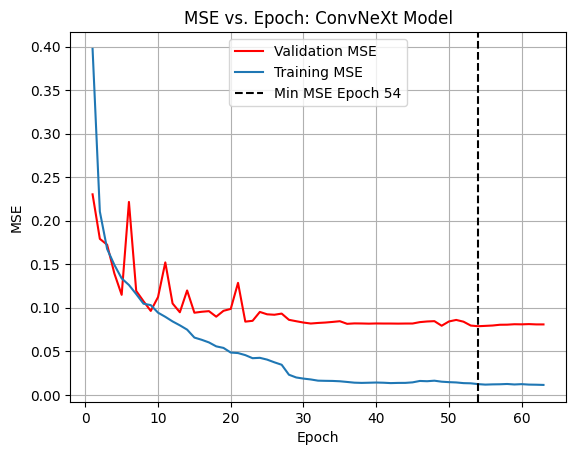

In [27]:
import matplotlib.pyplot as plt

ConvNeXtLargehistory = {}
for key in ConvNeXtLargehistory_1.history:
    ConvNeXtLargehistory[key] = ConvNeXtLargehistory_1.history[key] + ConvNeXtLargehistory_2.history[key]

def plot_mse(history):
    train_mse = history['mse']  
    test_mse = history['val_mse']  
    epochs = list(range(1, len(test_mse) + 1)) 

    min_mse_epoch = epochs[test_mse.index(min(test_mse))]  
    min_val_mse = min(test_mse)  

    plt.plot(epochs, test_mse, color='red', label='Validation MSE')
    plt.plot(epochs, train_mse, label='Training MSE')
    
    plt.axvline(x=min_mse_epoch, color='black', linestyle='--', label=f'Min MSE Epoch {min_mse_epoch}')
    
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    #plt.ylim(0,0.6)
    plt.title('MSE vs. Epoch: ConvNeXt Model')

    plt.legend()
    plt.grid(True)
    plt.show()

plot_mse(ConvNeXtLargehistory)


In [28]:
ConvNeXtLarge_best_val_mse = min(ConvNeXtLargehistory['val_mse'])  
print(f"Best Validation MSE: {ConvNeXtLarge_best_val_mse}")


Best Validation MSE: 0.0787954181432724


In [29]:
import pickle

# Save the combined history dictionary
with open('ConvNeXtLargeSAM_9102025history.pkl', 'wb') as f:
    pickle.dump(ConvNeXtLargehistory, f)


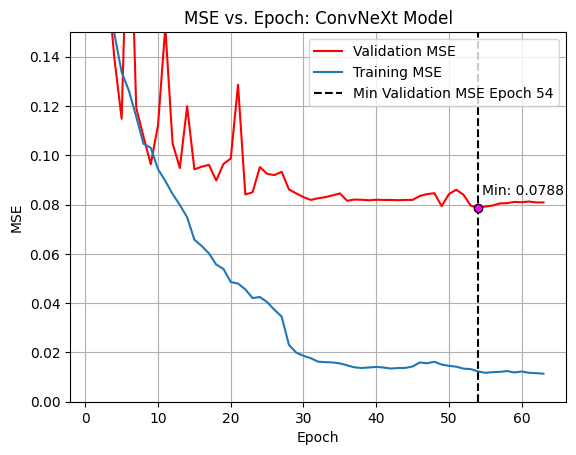

In [30]:
import matplotlib.pyplot as plt

ConvNeXtLargehistory = {}
for key in ConvNeXtLargehistory_1.history:
    ConvNeXtLargehistory[key] = ConvNeXtLargehistory_1.history[key] + ConvNeXtLargehistory_2.history[key]

def plot_mse(history):
    train_mse = history['mse']  
    test_mse = history['val_mse']  
    epochs = list(range(1, len(test_mse) + 1)) 

    min_mse_epoch = epochs[test_mse.index(min(test_mse))]  
    min_val_mse = min(test_mse)  

    plt.plot(epochs, test_mse, color='red', label='Validation MSE')
    plt.plot(epochs, train_mse, label='Training MSE')
    
    plt.axvline(x=min_mse_epoch, color='black', linestyle='--', label=f'Min Validation MSE Epoch {min_mse_epoch}')
    plt.scatter(min_mse_epoch, min_val_mse, color='magenta', edgecolor='black', zorder=5)
    
    plt.annotate(f'Min: {min_val_mse:.4f}',
                 xy=(min_mse_epoch, min_val_mse),
                 xytext=(min_mse_epoch + 0.5, min_val_mse + 0.005),  
                 fontsize=10)    
    
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.ylim(0,0.15)
    plt.title('MSE vs. Epoch: ConvNeXt Model')

    plt.legend()
    plt.grid(True)
    plt.show()

plot_mse(ConvNeXtLargehistory)


In [31]:
#duration in secs for the process to finish
end = time.time()
end - start

37482.00709319115